# Task4 海龟交易策略回测 Notebook

本 Notebook 用白盒方式展示海龟交易策略的核心流程，包括：价格通道计算、ATR 计算、突破信号生成、止损规则以及策略回测。

## 1. 核心概念

- **高低点通道**：过去若干日的最高价和最低价区间。
- **ATR**：平均真实波幅，用于衡量波动强度。
- **止损条件**：本次采用 `2 × ATR` 的波动性止损。
- **累计回报、最大回撤、夏普比率**：用于评价策略收益与风险。

In [1]:
import sys
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

base_dir = Path.cwd().resolve().parent
sys.path.insert(0, str(base_dir))

from turtle_utils import TurtleParams, apply_turtle_strategy, load_price_data, summarize_strategy

raw_dir = base_dir / 'raw_data'
processed_dir = base_dir / 'processed_data'
figures_dir = base_dir / 'figures'
default_params = TurtleParams(entry_window=20, exit_window=10, atr_window=20, stop_atr_multiplier=2.0)
metrics_df = pd.read_csv(processed_dir / 'turtle_strategy_metrics.csv')
metrics_df

,stock,entry_window,exit_window,atr_window,stop_atr_multiplier,sample_start,sample_end,buy_count,sell_count,stop_exit_count,channel_exit_count,benchmark_cumulative_return,strategy_cumulative_return,max_drawdown,sharpe_ratio,annualized_return,latest_atr
0,中国巨石（600176）,20,10,20,2.0,2024-01-02,2026-07-03,15,14,13,3,6.961819,1.286944,-0.220736,1.180298,0.412982,5.391
1,中国巨石（600176）,30,10,20,2.0,2024-01-02,2026-07-03,14,13,12,2,6.961819,1.040676,-0.180579,1.053546,0.347280,5.391
2,中国巨石（600176）,55,20,20,2.0,2024-01-02,2026-07-03,12,11,11,1,6.961819,0.832170,-0.218982,0.943790,0.287942,5.391
3,中际旭创（300308）,20,10,20,2.0,2024-01-02,2026-07-03,11,11,8,4,13.445667,6.778927,-0.268584,1.989483,1.356810,80.473
4,中际旭创（300308）,30,10,20,2.0,2024-01-02,2026-07-03,7,7,5,2,13.445667,7.076591,-0.200782,2.218051,1.394088,80.473
5,中际旭创（300308）,55,20,20,2.0,2024-01-02,2026-07-03,6,6,6,0,13.445667,3.987551,-0.200782,1.852897,0.957287,80.473


## 2. 以中国巨石为例计算海龟策略

下面展示从原始股价数据出发，计算通道、ATR、止损线和交易信号。

In [2]:
jushi = load_price_data(raw_dir / 'china-jushi_600176.csv')
jushi_strategy = apply_turtle_strategy(jushi, default_params.entry_window, default_params.exit_window, default_params.atr_window, default_params.stop_atr_multiplier)
jushi_strategy[['date', 'close', 'entry_high', 'exit_low', 'atr', 'buy_signal', 'sell_signal', 'sell_reason', 'position']].tail(15)

,date,close,entry_high,exit_low,atr,buy_signal,sell_signal,sell_reason,position
589,2026-06-12,41.61,43.98,34.13,2.7930,False,False,,0.0
590,2026-06-15,45.77,44.16,34.13,2.9110,True,False,,1.0
591,2026-06-16,49.64,45.77,34.13,3.0150,False,False,,1.0
592,2026-06-17,54.60,50.20,34.13,3.2210,False,False,,1.0
593,2026-06-18,53.50,54.60,34.13,3.2710,False,False,,1.0
594,2026-06-22,58.38,54.99,34.13,3.3870,False,False,,1.0
595,2026-06-23,58.93,58.65,34.13,3.5740,False,False,,1.0
596,2026-06-24,64.82,62.60,37.00,3.7290,False,False,,1.0
597,2026-06-25,70.80,64.82,38.00,3.9320,False,False,,1.0
598,2026-06-26,74.12,71.30,38.00,4.0465,False,False,,1.0


In [3]:
jushi_summary = summarize_strategy(jushi_strategy, '中国巨石（600176）', default_params)
pd.Series(jushi_summary)

stock                          中国巨石（600176）
entry_window                             20
exit_window                              10
atr_window                               20
stop_atr_multiplier                     2.0
sample_start                     2024-01-02
sample_end                       2026-07-03
buy_count                                15
sell_count                               14
stop_exit_count                          13
channel_exit_count                        3
benchmark_cumulative_return        6.961819
strategy_cumulative_return         1.286944
max_drawdown                      -0.220736
sharpe_ratio                       1.180298
annualized_return                  0.412982
latest_atr                            5.391
dtype: object

## 3. 图表展示

以下图表展示了默认参数 `20/10/ATR20/2N` 下的交易信号图和净值曲线。

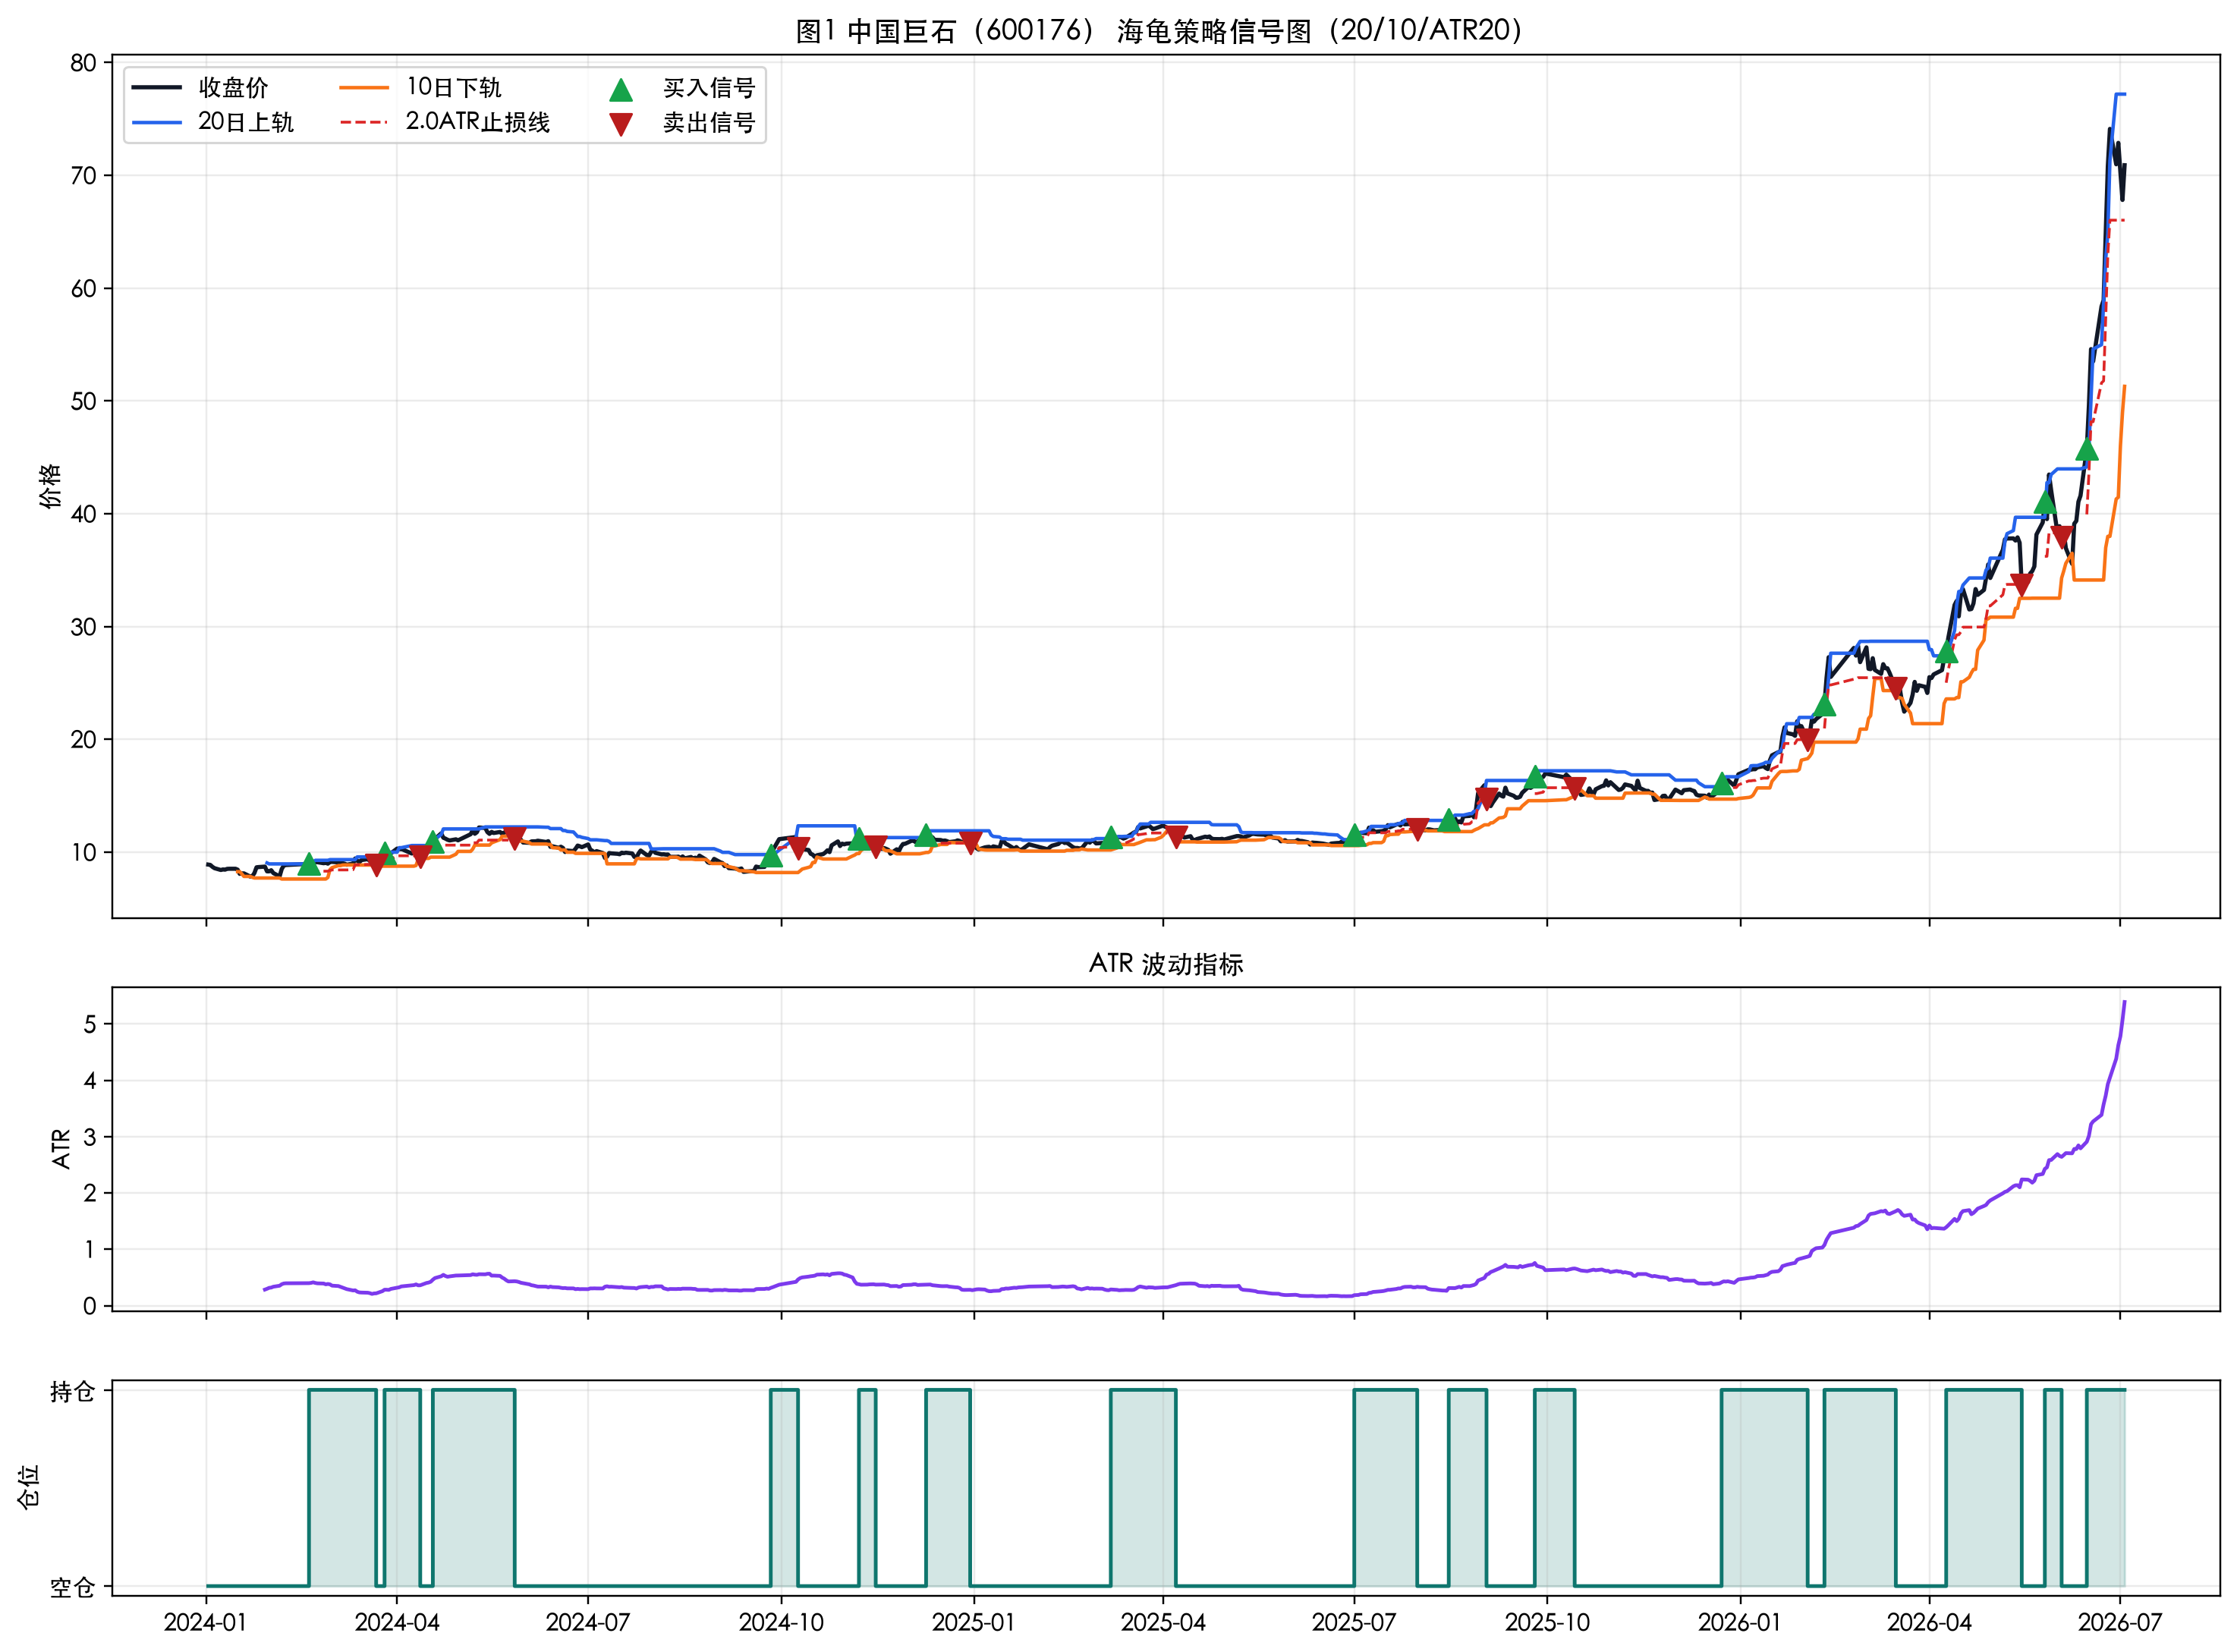

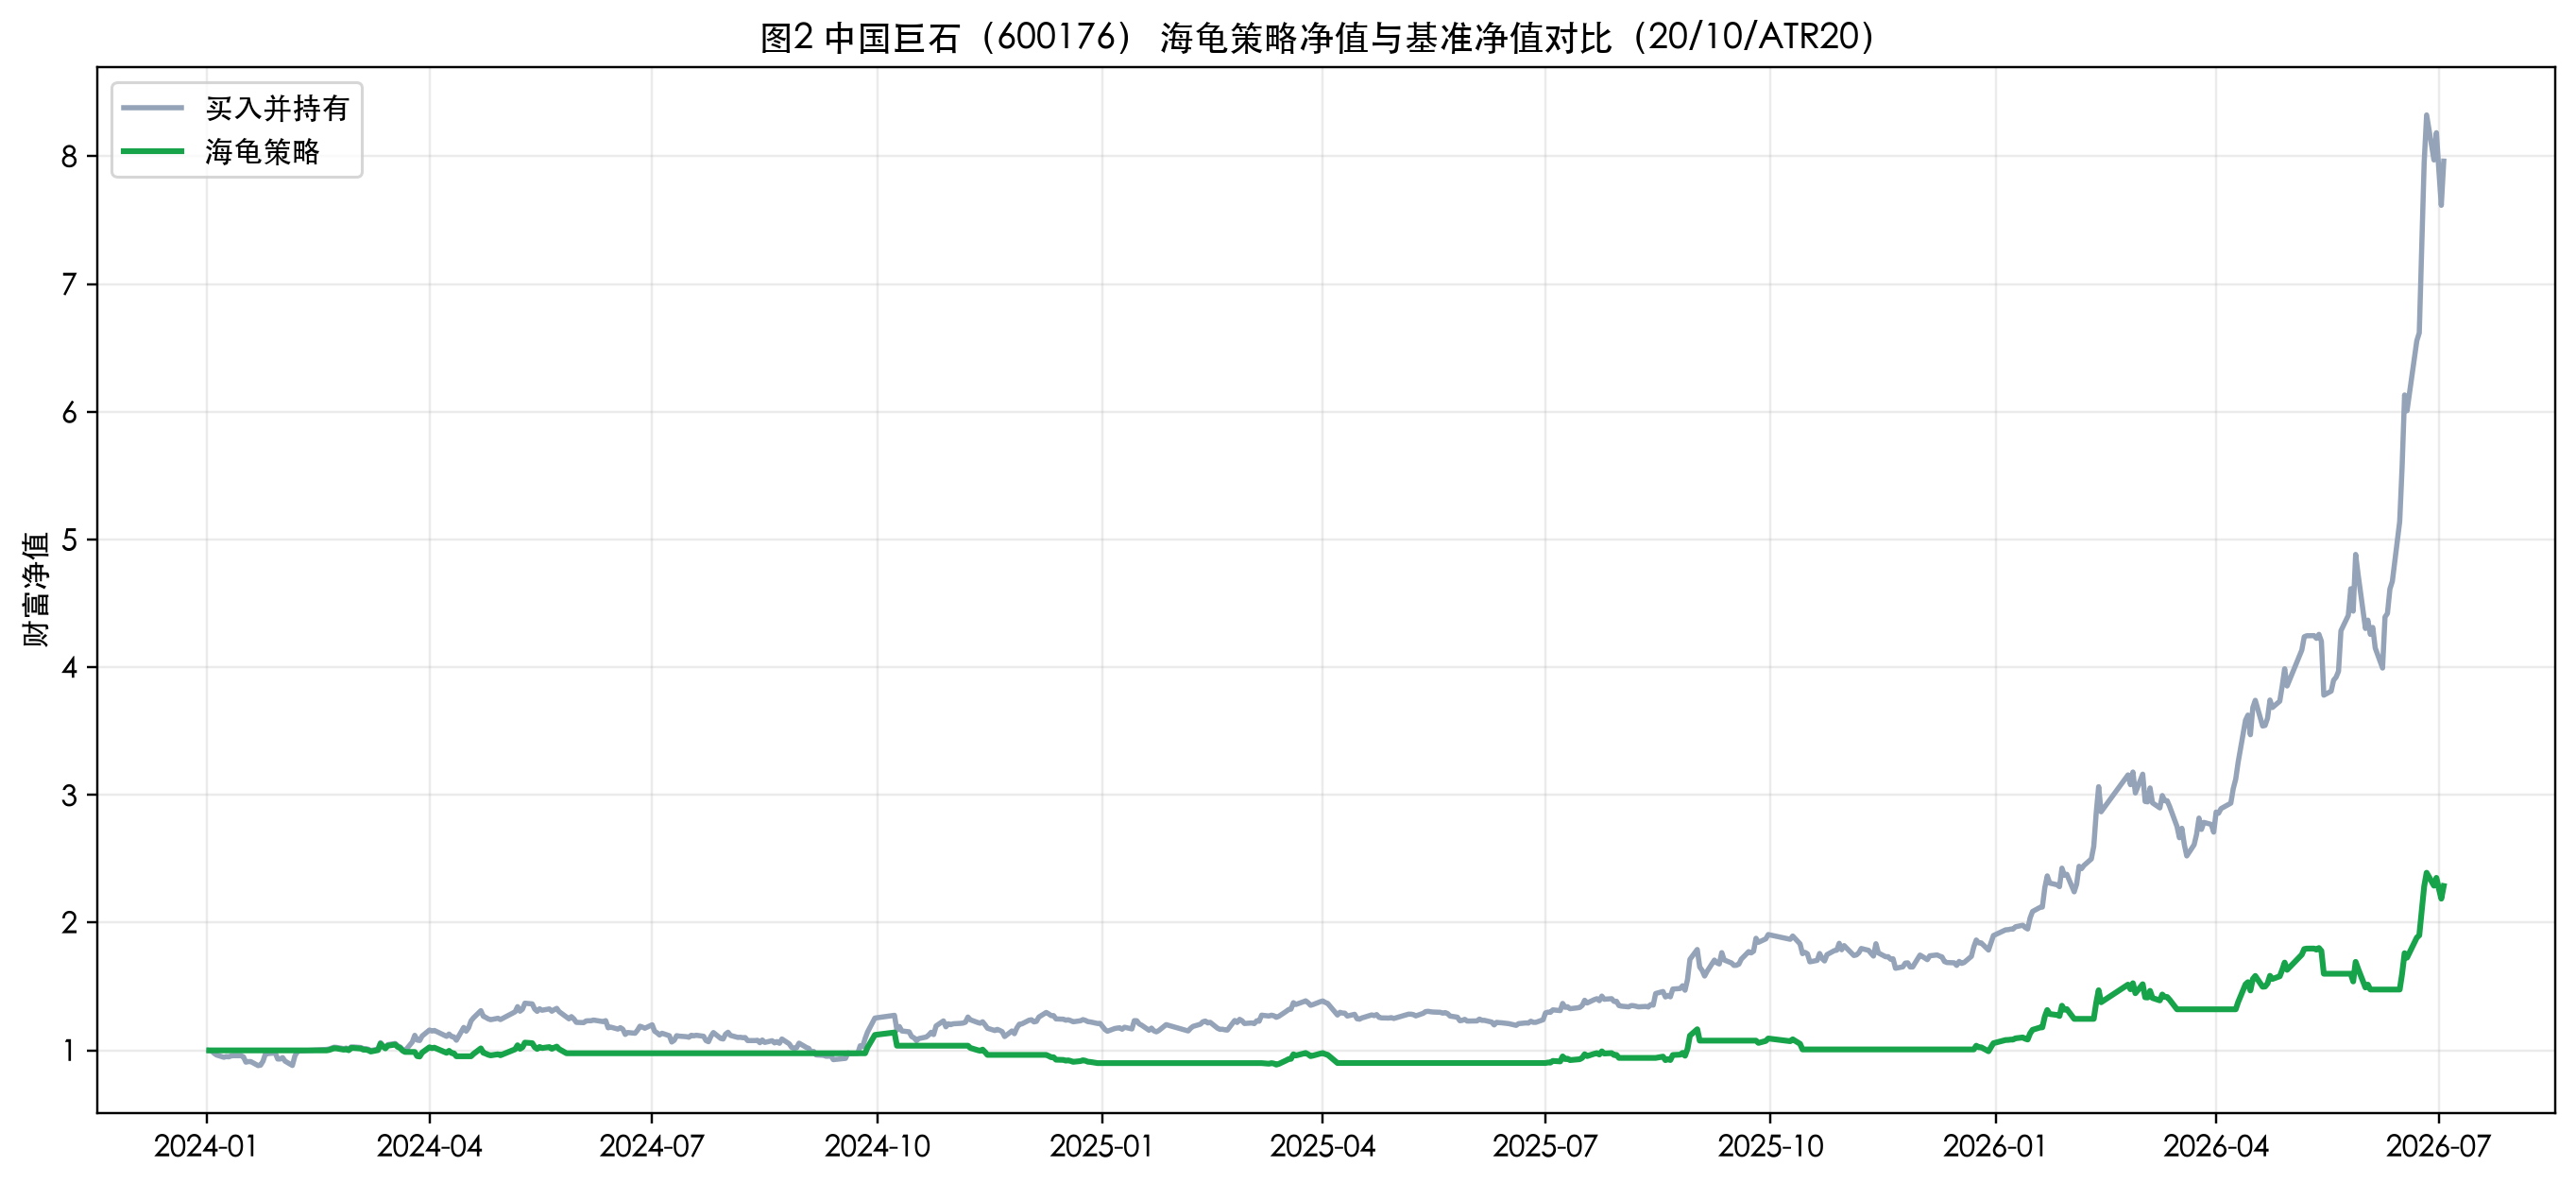

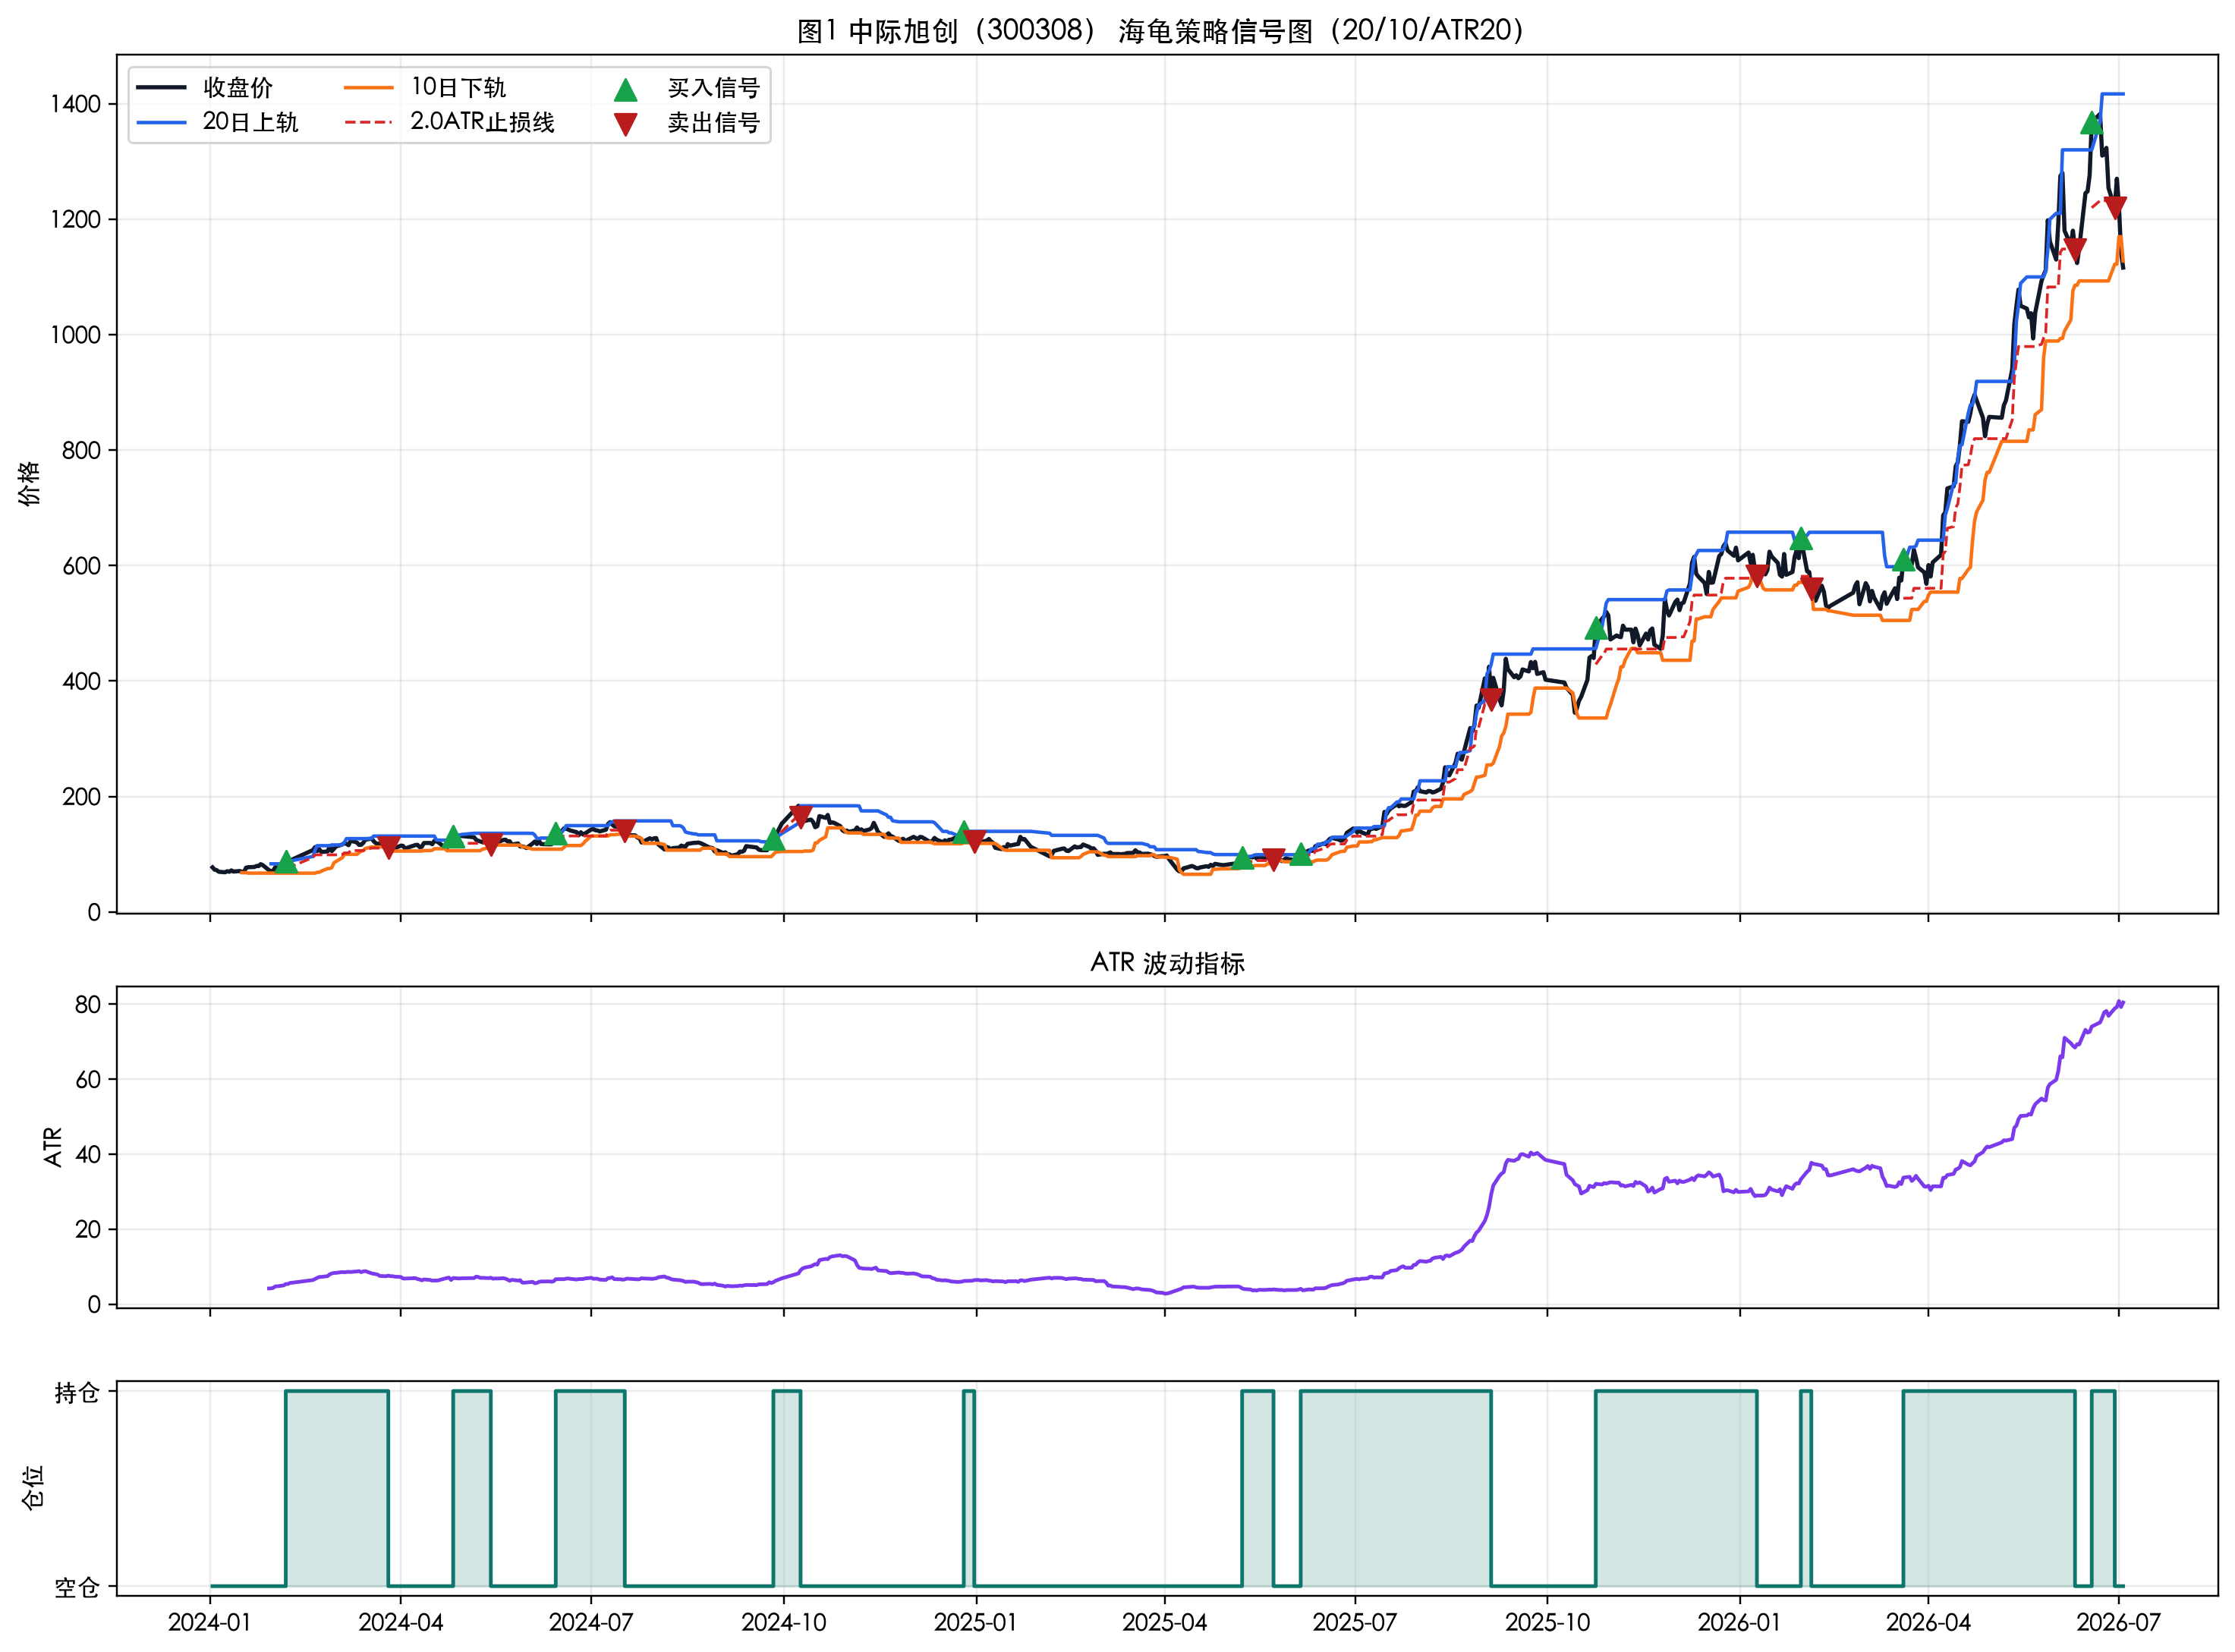

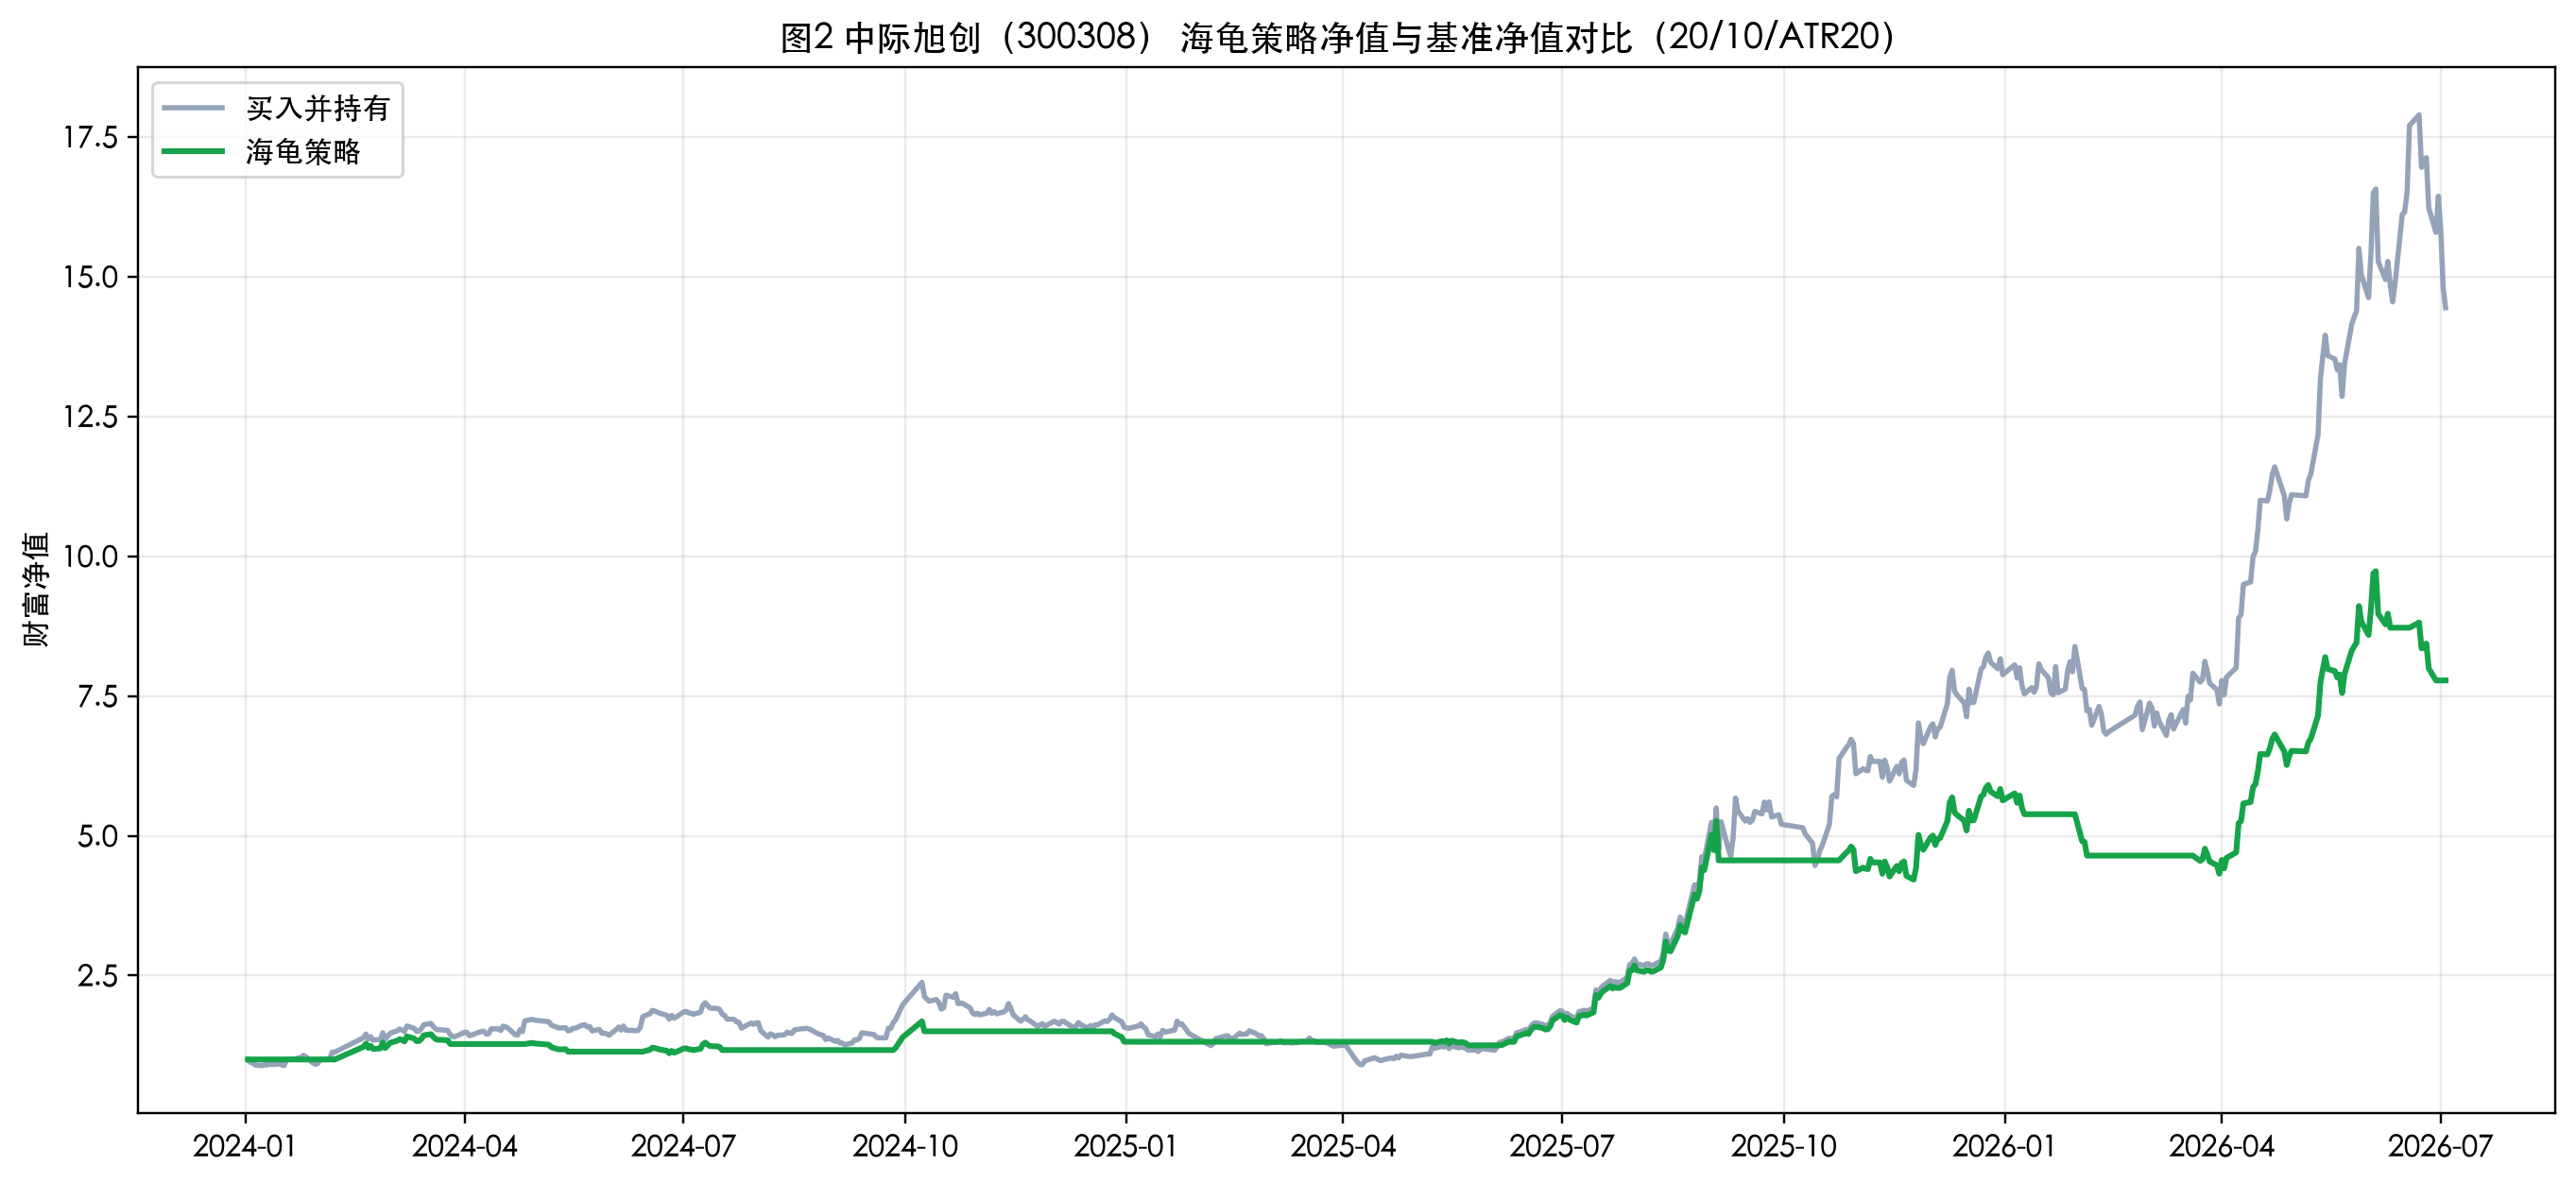

In [4]:
display(Image(filename=str(figures_dir / 'china_jushi_turtle_20_10_signals.png')))
display(Image(filename=str(figures_dir / 'china_jushi_turtle_20_10_equity.png')))
display(Image(filename=str(figures_dir / 'zhongji_xuchuang_turtle_20_10_signals.png')))
display(Image(filename=str(figures_dir / 'zhongji_xuchuang_turtle_20_10_equity.png')))

## 4. 不同通道参数比较

为了比较策略适应性，本次另外测试了 `30/10` 和 `55/20` 两组通道长度。

In [5]:
metrics_df[['stock', 'entry_window', 'exit_window', 'atr_window', 'stop_atr_multiplier', 'strategy_cumulative_return', 'max_drawdown', 'sharpe_ratio']]

,stock,entry_window,exit_window,atr_window,stop_atr_multiplier,strategy_cumulative_return,max_drawdown,sharpe_ratio
0,中国巨石（600176）,20,10,20,2.0,1.286944,-0.220736,1.180298
1,中国巨石（600176）,30,10,20,2.0,1.040676,-0.180579,1.053546
2,中国巨石（600176）,55,20,20,2.0,0.832170,-0.218982,0.943790
3,中际旭创（300308）,20,10,20,2.0,6.778927,-0.268584,1.989483
4,中际旭创（300308）,30,10,20,2.0,7.076591,-0.200782,2.218051
5,中际旭创（300308）,55,20,20,2.0,3.987551,-0.200782,1.852897


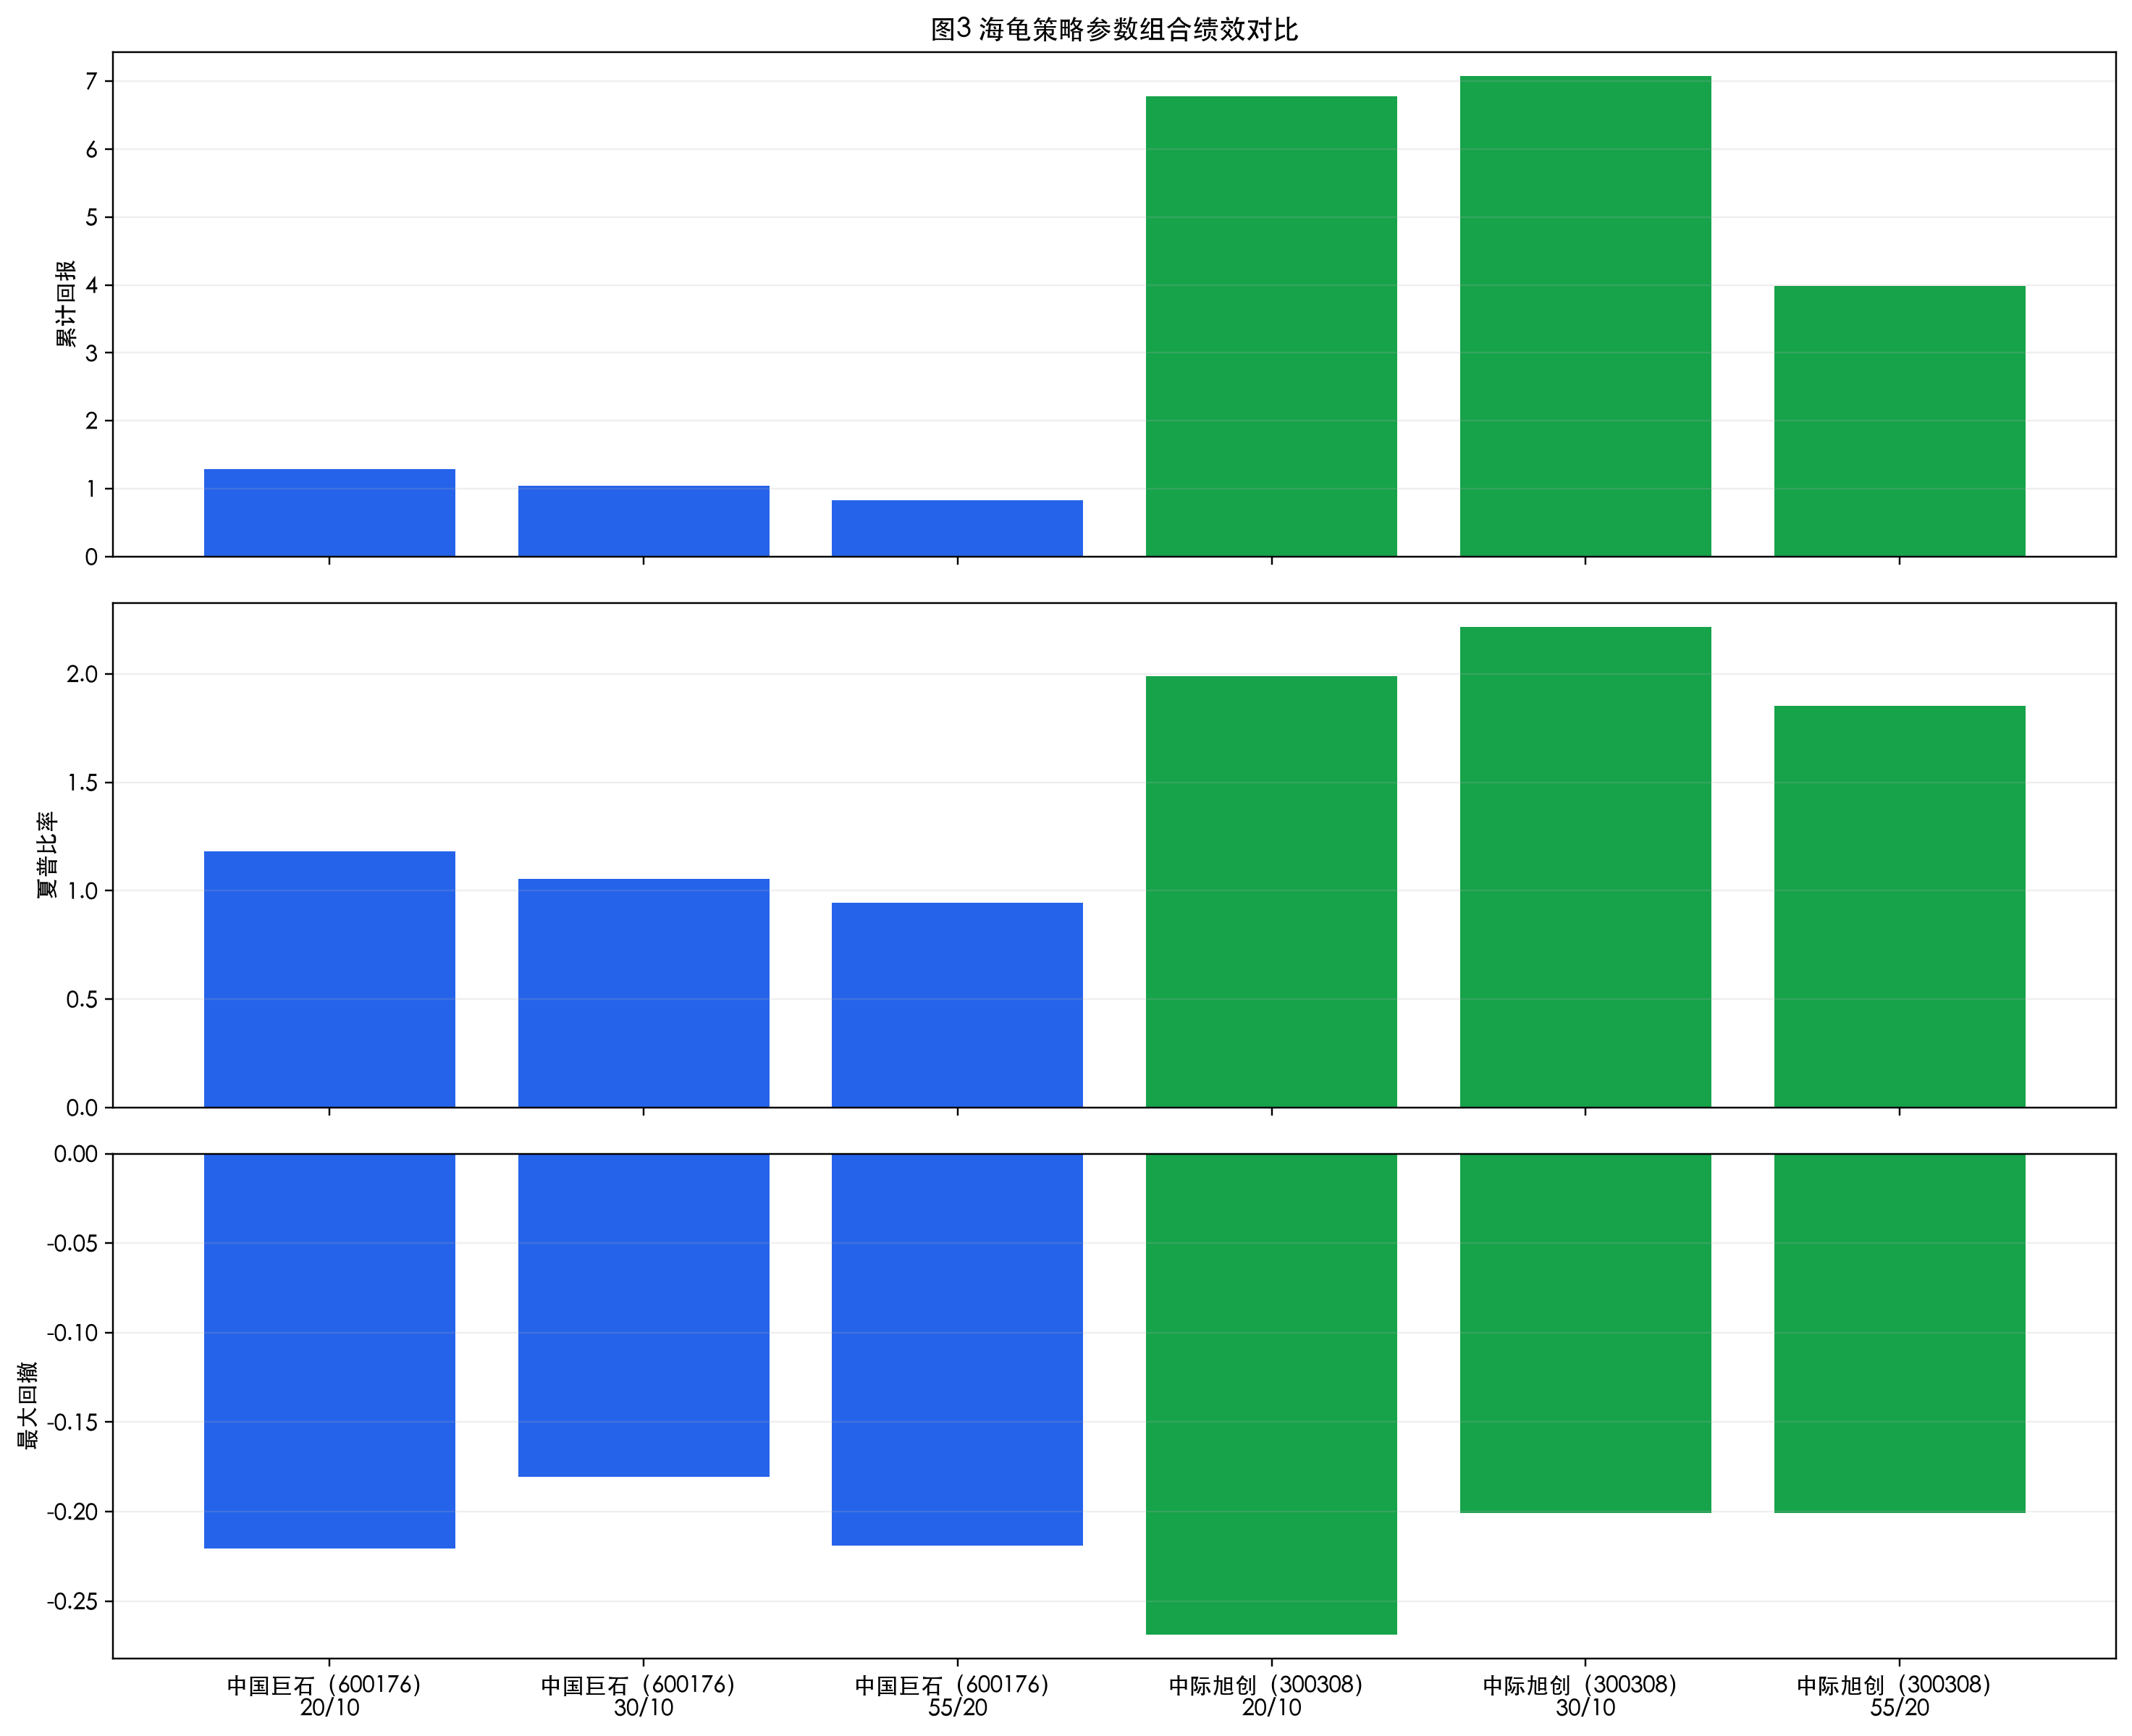

In [6]:
display(Image(filename=str(figures_dir / 'turtle_strategy_metric_comparison.png')))

## 5. 观察总结

1. 海龟策略属于趋势突破策略，适合趋势明显的阶段。
2. ATR 有助于让止损规则随波动变化，而不是机械使用固定点位。
3. 更长的通道会减少交易次数，但也可能错过部分行情；更短的通道则更灵敏，但更容易受到噪声影响。